# Business risk

In [2]:
#Importing Libraries

In [3]:
import numpy as np
import pandas as pd

In [19]:
df = pd.read_csv("/users/adityasingh/Downloads/business_risk.csv")

In [20]:
df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [21]:
df.isnull().sum()

Bankrupt?                                                   0
 ROA(C) before interest and depreciation before interest    0
 ROA(A) before interest and % after tax                     0
 ROA(B) before interest and depreciation after tax          0
 Operating Gross Margin                                     0
                                                           ..
 Liability to Equity                                        0
 Degree of Financial Leverage (DFL)                         0
 Interest Coverage Ratio (Interest expense to EBIT)         0
 Net Income Flag                                            0
 Equity to Liability                                        0
Length: 96, dtype: int64

In [22]:
df.shape

(6819, 96)

In [25]:
df.columns

Index(['Bankrupt?', ' ROA(C) before interest and depreciation before interest',
       ' ROA(A) before interest and % after tax',
       ' ROA(B) before interest and depreciation after tax',
       ' Operating Gross Margin', ' Realized Sales Gross Margin',
       ' Operating Profit Rate', ' Pre-tax net Interest Rate',
       ' After-tax net Interest Rate',
       ' Non-industry income and expenditure/revenue',
       ' Continuous interest rate (after tax)', ' Operating Expense Rate',
       ' Research and development expense rate', ' Cash flow rate',
       ' Interest-bearing debt interest rate', ' Tax rate (A)',
       ' Net Value Per Share (B)', ' Net Value Per Share (A)',
       ' Net Value Per Share (C)', ' Persistent EPS in the Last Four Seasons',
       ' Cash Flow Per Share', ' Revenue Per Share (Yuan ¥)',
       ' Operating Profit Per Share (Yuan ¥)',
       ' Per Share Net profit before tax (Yuan ¥)',
       ' Realized Sales Gross Profit Growth Rate',
       ' Operating Profit

In [28]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Int

In [32]:
#Target Variable Check
df['Bankrupt?'].value_counts()

Bankrupt?
0    6599
1     220
Name: count, dtype: int64

In [33]:
#percentage
df['Bankrupt?'].value_counts(normalize=True) * 100

Bankrupt?
0    96.77372
1     3.22628
Name: proportion, dtype: float64

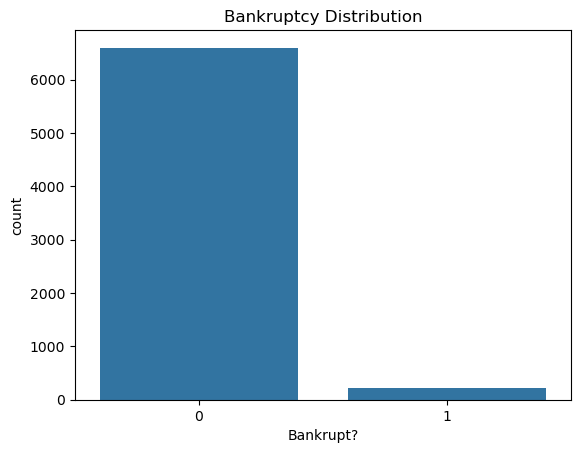

In [34]:
#Target Visualization
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Bankrupt?', data=df)
plt.title("Bankruptcy Distribution")
plt.show()

# Train Test Split + Feature/Target separate

In [39]:
#Feature and Target separate

X = df.drop('Bankrupt?', axis=1)
y = df['Bankrupt?']

print(X.shape)
print(y.shape)

(6819, 95)
(6819,)


In [40]:
#Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5455, 95)
Testing data: (1364, 95)


In [42]:
#Applying SMOTE(To fix imbalancing of dataset)
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_smote.value_counts())

Before SMOTE: Bankrupt?
0    5279
1     176
Name: count, dtype: int64
After SMOTE: Bankrupt?
0    5279
1    5279
Name: count, dtype: int64


In [43]:
# Now our data gets fully balanced now its learn bankrupt companies also which is approx 3% in starting

In [44]:
#Model Training

In [45]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

# Model initialize
rf = RandomForestClassifier(random_state=42)

# Model training
rf.fit(X_train_smote, y_train_smote)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [46]:
#RF prediction
y_pred = rf.predict(X_test)

In [47]:
#RF Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9611436950146628

Confusion Matrix:
[[1285   35]
 [  18   26]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1320
           1       0.43      0.59      0.50        44

    accuracy                           0.96      1364
   macro avg       0.71      0.78      0.74      1364
weighted avg       0.97      0.96      0.96      1364



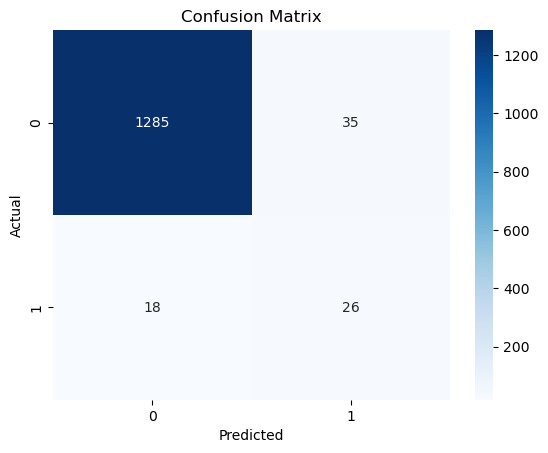

In [48]:
#Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [101]:
#XGBoosts(Default)
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(X_train_smote, y_train_smote)

y_pred_xgb = xgb.predict(X_test)

In [102]:
#XGBoost Evaluation
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1320
           1       0.48      0.55      0.51        44

    accuracy                           0.97      1364
   macro avg       0.73      0.76      0.75      1364
weighted avg       0.97      0.97      0.97      1364



[[1294   26]
 [  20   24]]


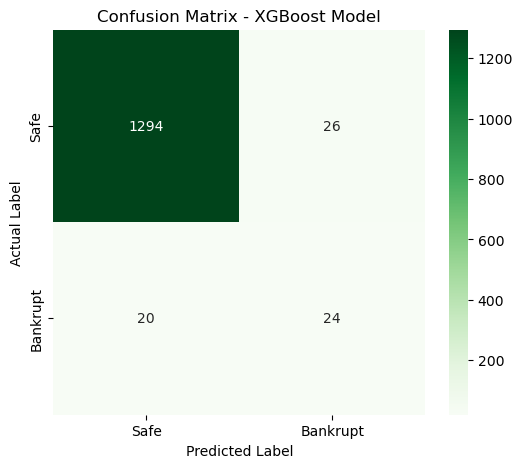

In [54]:
#XGBoost Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix calculate
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

print(cm_xgb)

# Heatmap plot
plt.figure(figsize=(6,5))

sns.heatmap(cm_xgb,
            annot=True,
            fmt='d',
            cmap='Greens',
            xticklabels=['Safe','Bankrupt'],
            yticklabels=['Safe','Bankrupt'])

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - XGBoost Model")

plt.show()

In [55]:
#Improving Recall for better prediction of bankrupt companies

In [76]:
#1. using Prediction Threshold( threshold=0.3 instead of 0.5)
# Probability prediction
y_prob = xgb.predict_proba(X_test)[:,1]

# Custom threshold
y_pred_custom = (y_prob > 0.20).astype(int)


In [77]:
#Evaluation 
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1320
           1       0.34      0.70      0.46        44

    accuracy                           0.95      1364
   macro avg       0.67      0.83      0.72      1364
weighted avg       0.97      0.95      0.96      1364



In [103]:
#2. scale_pos_weight(Minority class ko extra importance dena)

#XGBOOST(Threshold tuned)
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=10,
    random_state=42
)

xgb.fit(X_train_smote, y_train_smote)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [104]:
#3. Random Forest with class weight
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    class_weight={0:1, 1:5},
    n_estimators=300,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


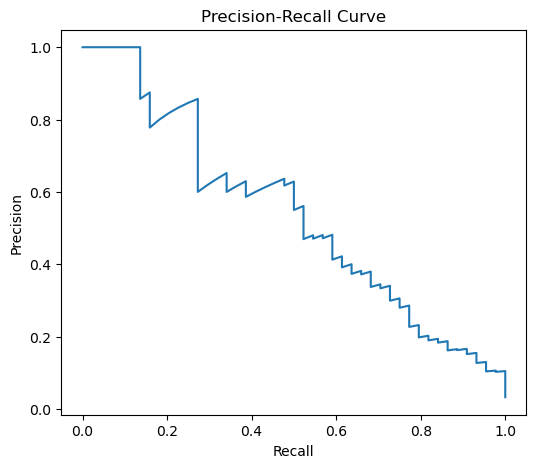

In [73]:
#Precision Recall Curve(Ye best threshold automatically find karta hai)
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

y_prob = xgb.predict_proba(X_test)[:,1]

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [78]:
#Hyperparameter Tunning

In [105]:
#XGBoosts(Hyperparameter Tuned)
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42)

param_grid = {
    'n_estimators': [200,300,400,500],
    'max_depth': [3,4,5,6,7],
    'learning_rate': [0.01,0.03,0.05,0.1],
    'subsample': [0.7,0.8,0.9],
    'colsample_bytree': [0.7,0.8,0.9]
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=20,
    scoring='recall',
    cv=3,
    verbose=1,
    n_jobs=-1
)

random_search.fit(X_train_smote, y_train_smote)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], 'n_estimators': [200, 300, ...], ...}"
,n_iter,20
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [80]:
#Best Parameter
print(random_search.best_params_)

{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.7}


In [81]:
#Best Model
best_model = random_search.best_estimator_

y_pred_best = best_model.predict(X_test)

In [82]:
#Evaluation 
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1320
           1       0.50      0.52      0.51        44

    accuracy                           0.97      1364
   macro avg       0.74      0.75      0.75      1364
weighted avg       0.97      0.97      0.97      1364



In [83]:
y_prob = best_model.predict_proba(X_test)[:,1]

y_pred_final = (y_prob > 0.25).astype(int)

In [84]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1320
           1       0.42      0.59      0.49        44

    accuracy                           0.96      1364
   macro avg       0.70      0.78      0.73      1364
weighted avg       0.97      0.96      0.96      1364



In [86]:
#Optuna 
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import recall_score

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 600),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
    }

    model = XGBClassifier(**params, random_state=42)

    model.fit(X_train_smote, y_train_smote)

    y_pred = model.predict(X_test)

    recall = recall_score(y_test, y_pred)

    return recall

In [87]:
#Running optimizztion(optuna)
study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=30)

[I 2026-03-15 16:58:08,047] A new study created in memory with name: no-name-206323ba-2e23-4c8f-b75b-aad2961e7191
[I 2026-03-15 16:58:08,958] Trial 0 finished with value: 0.4772727272727273 and parameters: {'n_estimators': 298, 'max_depth': 6, 'learning_rate': 0.18873923426266756, 'subsample': 0.70934085222483, 'colsample_bytree': 0.637282730196781}. Best is trial 0 with value: 0.4772727272727273.
[I 2026-03-15 16:58:11,118] Trial 1 finished with value: 0.5227272727272727 and parameters: {'n_estimators': 570, 'max_depth': 8, 'learning_rate': 0.06859166683521062, 'subsample': 0.7903244517695247, 'colsample_bytree': 0.7801329014891071}. Best is trial 1 with value: 0.5227272727272727.
[I 2026-03-15 16:58:11,996] Trial 2 finished with value: 0.5227272727272727 and parameters: {'n_estimators': 483, 'max_depth': 3, 'learning_rate': 0.07325798067475411, 'subsample': 0.7908345642039857, 'colsample_bytree': 0.8107977066639843}. Best is trial 1 with value: 0.5227272727272727.
[I 2026-03-15 16:58

In [88]:
#Best Parameter
print(study.best_params)

{'n_estimators': 221, 'max_depth': 4, 'learning_rate': 0.014213787150157007, 'subsample': 0.9221597846222068, 'colsample_bytree': 0.8958771224995197}


In [90]:
#Best Model
best_model = XGBClassifier(**study.best_params)

best_model.fit(X_train_smote, y_train_smote)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8958771224995197
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [95]:
#Shap Values
import shap

#SHAP Explainer
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

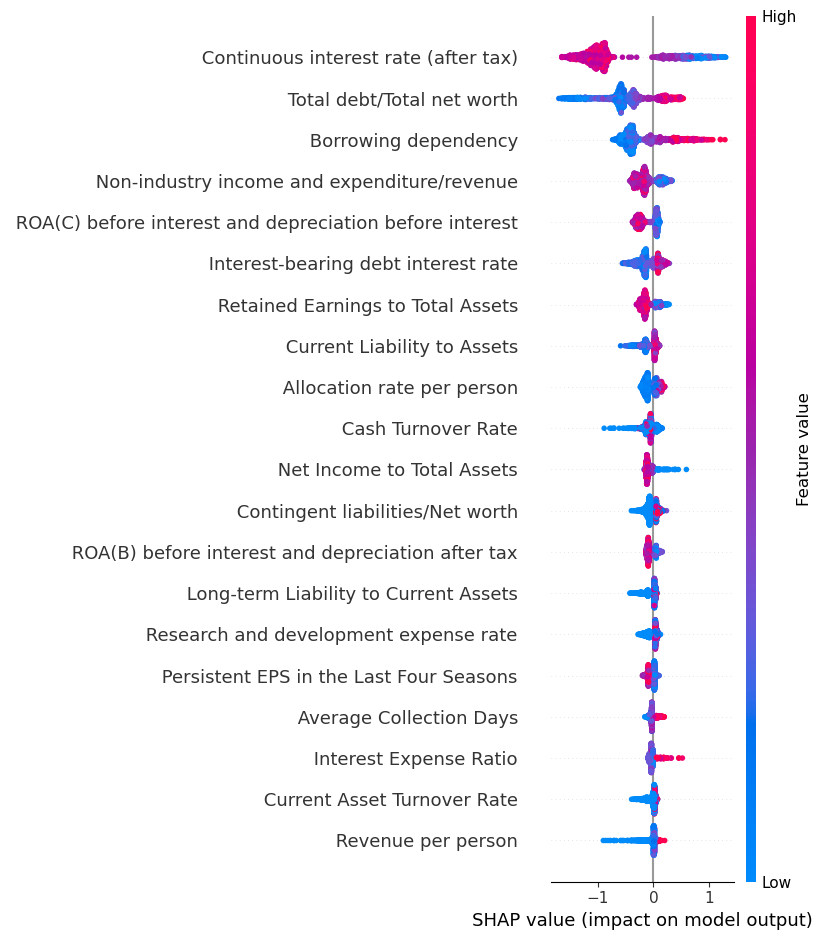

In [96]:
#SHAP summary plot
shap.summary_plot(shap_values, X_test)

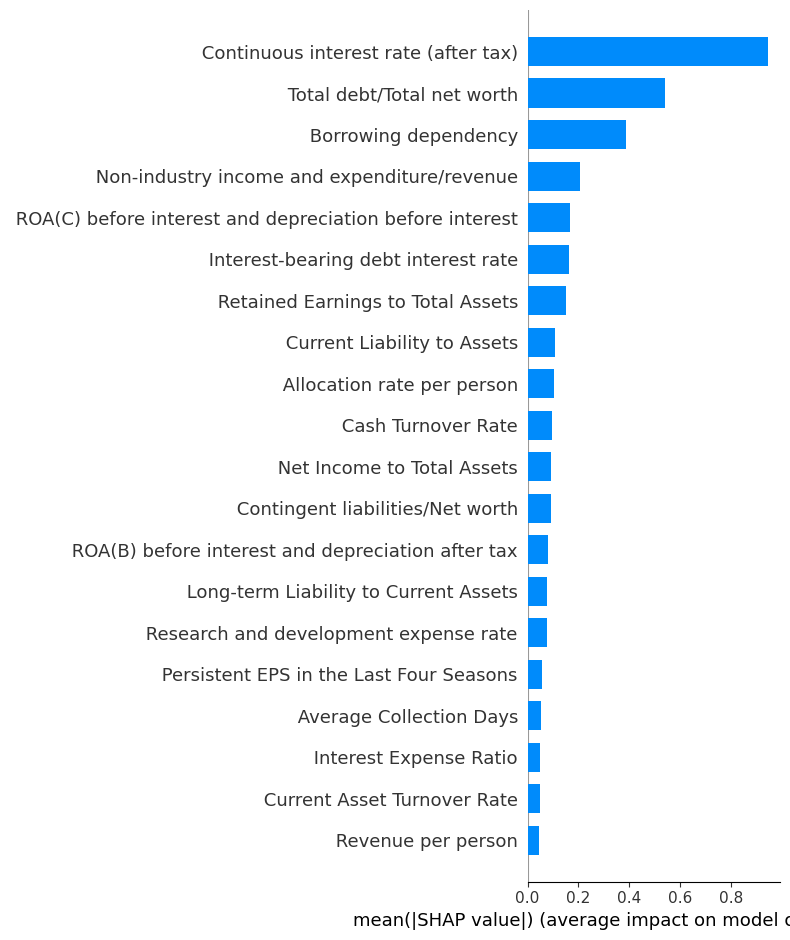

In [97]:
#SHAP Feature importance plot
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [98]:
#Single prediction explaination
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0]
)

In [100]:
# Model comparison results
results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost (Default)",
        "XGBoost (Hyperparameter Tuned)",
        "XGBoost (Threshold Tuned)"
    ],
    
    "Accuracy": [0.96, 0.97, 0.96, 0.95],
    
    "Precision (Risk)": [0.43, 0.48, 0.50, 0.34],
    
    "Recall (Risk)": [0.59, 0.55, 0.52, 0.70],
    
    "F1 Score": [0.50, 0.51, 0.51, 0.46]
})

results

,Model,Accuracy,Precision (Risk),Recall (Risk),F1 Score
0,Random Forest,0.96,0.43,0.59,0.50
1,XGBoost (Default),0.97,0.48,0.55,0.51
2,XGBoost (Hyperparameter Tuned),0.96,0.50,0.52,0.51
3,XGBoost (Threshold Tuned),0.95,0.34,0.70,0.46


### Among all evaluated models, the threshold-tuned XGBoost model achieved the highest recall (0.70), which is important for detecting bankruptcy risk. Therefore, it was selected as the final model for business risk prediction.

In [106]:
#Trained XGBoost model saving
import joblib

joblib.dump(best_model, "xgboost_business_risk_model.pkl")

['xgboost_business_risk_model.pkl']

In [107]:
#Threshold value model
threshold = 0.25

joblib.dump(threshold, "risk_threshold.pkl")

['risk_threshold.pkl']